In [89]:
import pickle
from pathlib import Path

from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import DataLoader

In [90]:
# from generate_data.py
with open("dataset.pickle", "rb") as f:
    dataset = pickle.load(f)

In [94]:
print(f"Dataset size: {len(dataset)}")

# Test loading a sample
img, flow = dataset[0]
print(f"Image shape: {img.shape}")
print(f"Flow shape: {flow.shape}")

# Test with DataLoader
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

print()
for img_batch, flow_batch in dataloader:
    print(f"Image batch shape: {img_batch.shape}")
    print(f"Flow batch shape: {flow_batch.shape}")
    break

Dataset size: 500
Image shape: torch.Size([2, 256, 256])
Flow shape: torch.Size([2, 256, 256])

Image batch shape: torch.Size([4, 2, 256, 256])
Flow batch shape: torch.Size([4, 2, 256, 256])


In [4]:
split = int(len(dataset) * 0.9)

data_train = dataset[:split]
data_val = dataset[split:]

print(f"Training set size = {len(data_train)}")
print(f"Training set size = {len(data_val)}")

Training set size = 450
Training set size = 50


In [5]:
train_loader = DataLoader(data_train, batch_size=8, shuffle=True)
val_loader = DataLoader(data_val, batch_size=8, shuffle=False)

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [62]:
from model import ResNet

In [63]:
model = ResNet(base_ch=32)

# Around a million is probably ok for this
print("number of parameters: ", sum([x.numel() for x in model.parameters()]))

number of parameters:  1065698


In [ ]:
# Loading pretrained checkpoint
# model.load_state_dict(torch.load("model_a.ckpt", weights_only=True))

In [49]:
# 1e-4 is a good starting value
lr = 1e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

In [ ]:
# Penalty for smoothness
# Calculate the magnitude of the spatial derivatives
def smoothness_loss(pred):
    dx = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    dy = pred[:, :, 1:, :] - pred[:, :, :-1, :]

    return torch.mean(torch.abs(dx)) + torch.mean(torch.abs(dy))


# Main loss function
mse_loss = nn.MSELoss()

In [52]:
# Quite a lot but you can keep training as long as validation loss goes down
n_epoch = 200

In [ ]:
model.to(device)

ema_loss = None
losses = []
ema_losses = []
global_step = 0
val_losses = []
val_loss = 0

for epoch in range(n_epoch):
    model.train()
    for x, target in train_loader:
        x = x.to(device)
        target = target.to(device)

        pred = model(x)

        l_mse = mse_loss(pred, target)
        l_smooth = smoothness_loss(pred)

        # The factor here is kind of arbitrary
        loss = l_mse + 0.2 * l_smooth

        # optimizer step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # bookkeeping
        global_step += 1
        ema_loss_decay = max(0.01, (1 / global_step))
        ema_loss = ema_loss or loss.item()
        ema_loss += ema_loss_decay * (loss.item() - ema_loss)

        losses.append(loss.item())
        ema_losses.append(ema_loss)

        print(
            f"\r[{epoch}/{n_epoch}], {ema_loss:7.5f}, {loss:7.5f}, {val_loss:7.5f} ",
            end="",
        )

    model.eval()
    val_loss = []
    for x, target in val_loader:
        x = x.to(device)
        target = target.to(device)
        pred = model(x)
        # Note we don't use penalty in validation
        loss = mse_loss(pred, target)
        val_loss.append(loss.item())

    val_loss = np.average(np.array(val_loss))
    val_losses.append(val_loss)

In [54]:
print(f"final validation loss: {val_losses[-1]:.4f}")

final validation loss: 0.0181


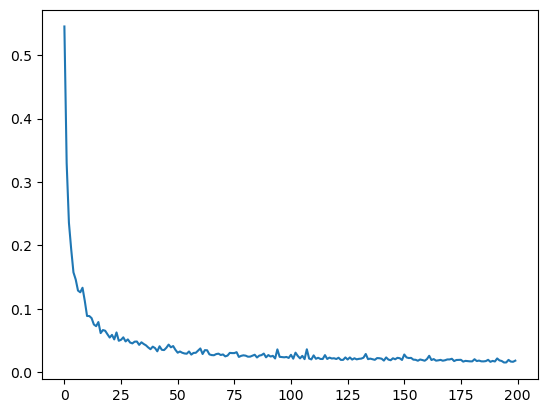

In [99]:
plt.plot(val_losses)
# plt.yscale("log")
plt.show()

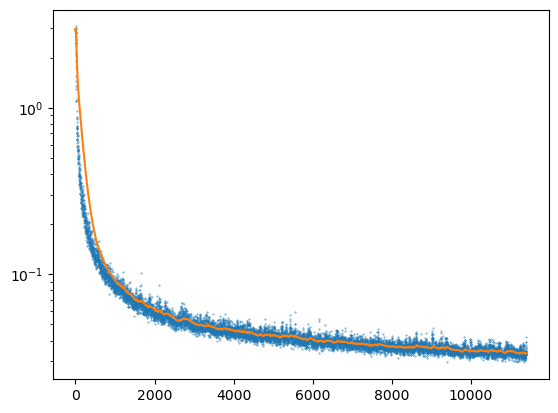

In [95]:
plt.scatter(np.arange(len(losses)), losses, s=0.1)
plt.plot(ema_losses, c="tab:orange")
plt.yscale("log")
plt.show()

In [85]:
img, flow = data_val[0]
# img, flow = data_train[0]

(-0.5, 255.5, 255.5, -0.5)

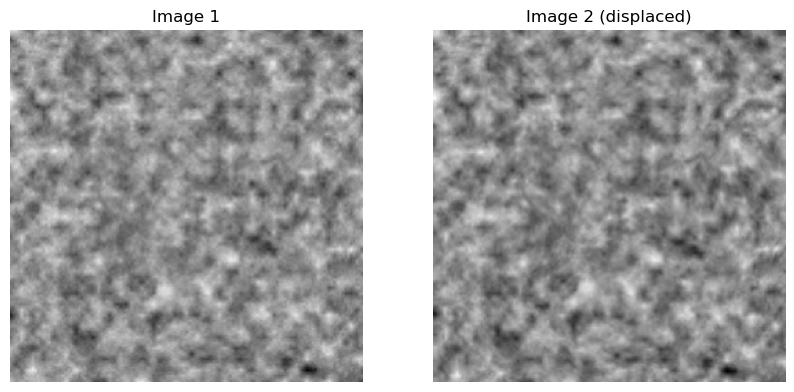

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(10, 10))
axes[0].imshow(img[0].squeeze(), cmap="gray")
axes[0].set_title("Image 1")
axes[0].axis("off")
axes[1].imshow(img[1].squeeze(), cmap="gray")
axes[1].set_title("Image 2 (displaced)")
axes[1].axis("off")

In [96]:
# Draw velocity field using red and green channels
def vel_to_rgb(flow):
    rgb = np.stack((flow[0], flow[1], np.zeros_like(flow[0]))).transpose(1, 2, 0)
    rgb = rgb / np.max(np.abs(rgb))
    rgb = 0.5 + 0.5 * rgb
    return rgb

(-0.5, 255.5, 255.5, -0.5)

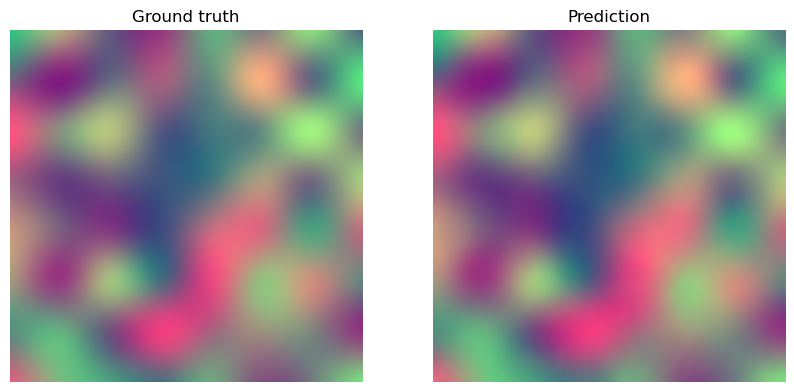

In [97]:
model.eval()
model.cpu()
with torch.no_grad():
    pred = model(img.unsqueeze(0)).numpy().squeeze()

fig, axes = plt.subplots(1, 2, figsize=(10, 10))
axes[0].imshow(vel_to_rgb(flow))
axes[0].set_title("Ground truth")
axes[0].axis("off")
axes[1].imshow(vel_to_rgb(pred))
axes[1].set_title("Prediction")
axes[1].axis("off")

In [98]:
torch.save(model.state_dict(), "model_a.ckpt")